In [46]:
library(Seurat)

In [107]:
input_files <- c('/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0322_NT_1_3000_dir/filtered_annotated_CRC0322_NT_1_3000.tsv',
                 '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0327_NT_2_dir/filtered_annotated_CRC0327_NT_2.tsv', 
                 '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_longer/CRC0542_NT72h_1_dir/filtered_annotated_CRC0542_NT72h_1.tsv')
                 
samples <- c('CRC0322', 'CRC0327', 'CRC0542')

#filtergenes <- ''
#or 
filtergenes <- 'Graphs/grafo_filtrato_undirect_small.csv'

if (filtergenes != '') {
    nfeatures <- 949
    npc <- 20
    resolution <- 0.15 # even with 0.8 we do not get a better cluster 4 # big jump 0.1 - 0.2 ?
    # 0.12 with 20 npc for 5 clusters
    # 0.3 for 200 for 4 clusters
} else {
    nfeatures <- 1000
    npc <- 20
    resolution <- 0.1
}

# test 2 extreme res + contingency 
# test scale 

In [108]:
genes <- read.csv(filtergenes)
keepg <- unique(c(genes$source))
length(keepg)

[1] 949

In [109]:
# create seurat objects and integrates
input_files_l <- unlist(strsplit(input_files, ','))

createSeurat <- function(file, genes) {
  df <- read.table(gzfile(file), sep=',', header=TRUE, row.names=1)
  keep <- sapply(rownames(df), function(x) {g <- strsplit(x, ':')[1][[1]]; g[2] %in% genes}) ## double trouble
  df <- df[keep,] ## double trouble
  genes <- sapply(rownames(df), function(x) {g <- strsplit(x, ':')[1][[1]]; g[2] })
  ng <- as.data.frame(table(genes))
  genes <- ng[ng$Freq == 1, 'genes']
  keep <- sapply(rownames(df), function(x) {g <- strsplit(x, ':')[1][[1]]; g[2] %in% genes})
  df <- df[keep,]
  rownames(df) <- sapply(rownames(df), function(x) {g <- strsplit(x, ':')[1][[1]]; g[2] })  # noia per il ciclo ho solo gli ENSG disponibili al volo :(
  res <- CreateSeuratObject(df)
  return(res)
}

data_list <- lapply(input_files_l, createSeurat, keepg)

data_list <- lapply(X = data_list, FUN = function(x) {
    x <- NormalizeData(x)
    x <- ScaleData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = nfeatures)
    
})

features <- SelectIntegrationFeatures(object.list = data_list, nfeatures= nfeatures)
anchors <- FindIntegrationAnchors(object.list = data_list, anchor.features = features, dims=1:npc)# paneth split in two clusters in this way
sdata <- IntegrateData(anchorset = anchors, dims=1:npc) 
DefaultAssay(sdata) <- "integrated"



Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Warning message in CheckDuplicateCellNames(object.list = object.list):
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Scaling features for provided objects

Finding all pairwise anchors

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 10388 anchors

Filtering anchors

	Retained 3766 anchors

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 9347 anchors

Filtering anchors

	Retained 3500 anchors

Warning message:
“Layer counts isn't present in the assay obj

In [110]:
#skip integration and map to each samples, otherwise we do not have enough data to map. How did they do it?
#sdata <- data_list[[1]]
# or
sdata <- IntegrateData(anchorset = anchors, dims=1:npc) 
sdata_int_backup <- sdata

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Merging dataset 1 into 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Merging dataset 3 into 2 1

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


In [111]:
sdata <- ScaleData(sdata, verbose = FALSE)
sdata <- RunPCA(sdata, verbose = FALSE, npcs = npc)
sdata <- RunUMAP(sdata, reduction = "pca", dims = 1:npc, verbose=F)
#DimPlot(sdata, reduction = "umap", group.by='cycle')


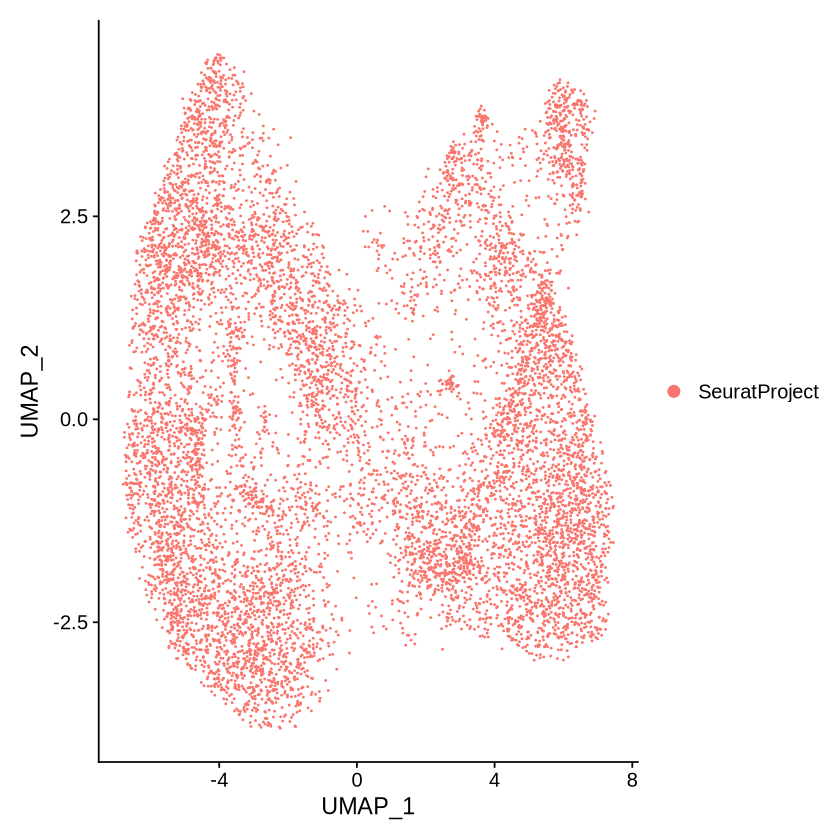

In [112]:
#UMAP with samples
#cells <- colnames(sdata)

#samples_n <- sapply(strsplit(cells, "_"), function(x){x[[2]]})
#sdata$sample <- samples[as.numeric(samples_n)]
#DimPlot(sdata, reduction = "umap", group.by='sample')
DimPlot(sdata, reduction = "umap")

In [76]:
# tejpar
tej <- readRDS('/mnt/cold1/snaketree/data/tejpar_scRNA/i2_i3_all_merged_sr1_obj.Rds')


In [87]:
tej <- NormalizeData(tej)
tej <- ScaleData(tej)
tej <- FindVariableFeatures(tej, selection.method = "vst", nfeatures = nfeatures)
tej <- RunPCA(tej, verbose = FALSE, npcs = npc)
tej

Centering and scaling data matrix



An object of class Seurat 
35952 features across 51444 samples within 2 assays 
Active assay: RNA (33538 features, 1000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: integrated
 1 dimensional reduction calculated: pca

In [88]:
gt <- rownames(tej)
gm <- rownames(sdata)
length(intersect(gt, gm))
length(gt)
length(gm)

[1] 19008

[1] 33538

[1] 19354

In [113]:
tvar_genes <- VariableFeatures(tej)
mvar_genes <- VariableFeatures(sdata)
length(intersect(tvar_genes, mvar_genes))


[1] 63

In [114]:
DefaultAssay(sdata) <- "RNA"
tej.anchors <- FindTransferAnchors(reference = tej, query = sdata, dims = 1:npc,
    reference.reduction = "pca")#, features=intersect(gt, gm))
predictions <- TransferData(anchorset = tej.anchors, refdata = tej$celltype, dims = 1:npc)
sdata <- AddMetaData(sdata, metadata = predictions)

Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 2533 anchors

Filtering anchors

	Retained 522 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels



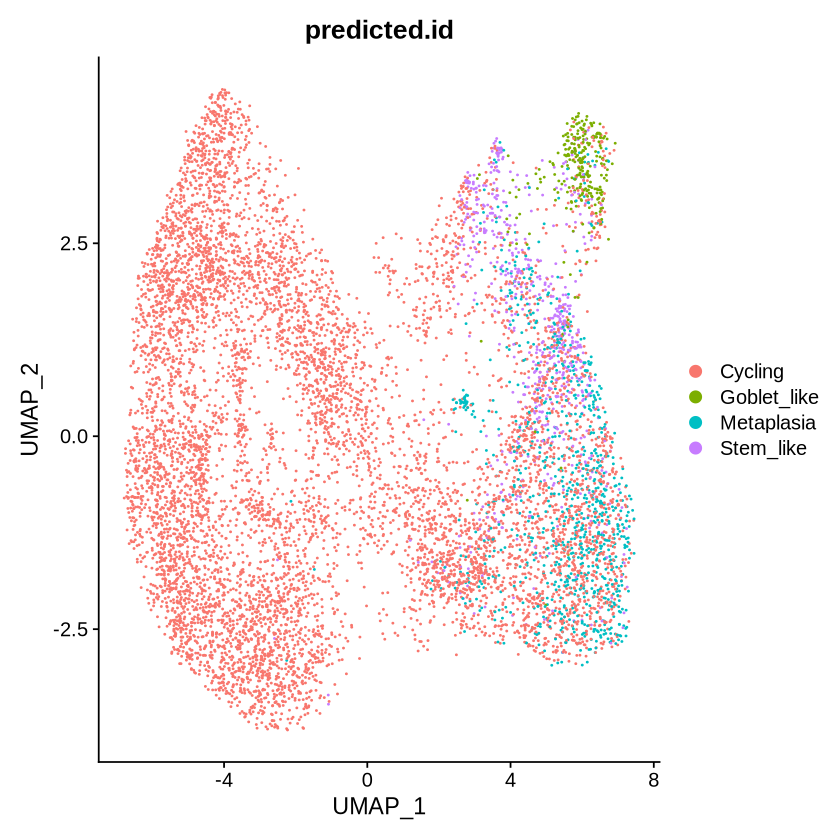

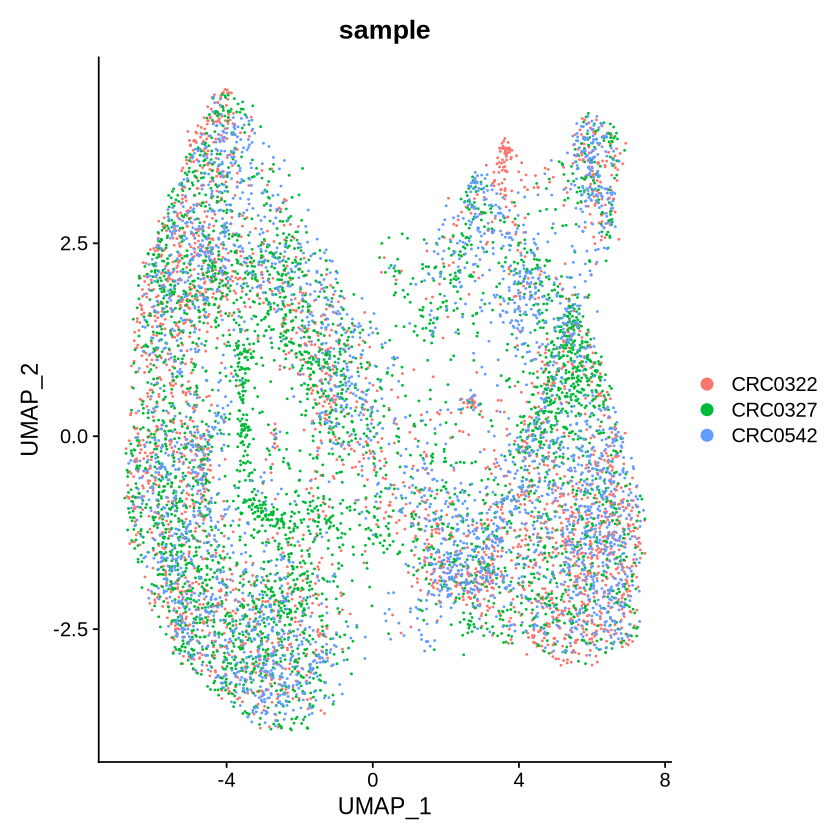

In [115]:
DimPlot(sdata, reduction = "umap", group.by='predicted.id')
cells <- colnames(sdata)

samples_n <- sapply(strsplit(cells, "_"), function(x){x[[2]]})
sdata$sample <- samples[as.numeric(samples_n)]
DimPlot(sdata, reduction = "umap", group.by='sample')

In [104]:
library(ggplot2) # da qui in poi regno del nulla estremo

In [103]:
tej <- RunUMAP(tej, dims = 1:npc, reduction = "pca", return.model = TRUE, verbose=F) # was integrated_cca, borf
#pancreas.query <- MapQuery(anchorset = pancreas.anchors, reference = pancreas.ref, query = pancreas.query,
#    refdata = list(celltype = "celltype"), reference.reduction = "pca", reduction.model = "umap")

sdata <- IntegrateEmbeddings(anchorset = tej.anchors, reference = tej, query = sdata,
    new.reduction.name = "ref.pca")
sdata <- ProjectUMAP(query = sdata, query.reduction = "ref.pca", reference = tej,
    reference.reduction = "pca", reduction.model = "umap")

p1 <- DimPlot(tej, reduction = "umap", group.by = "celltype", label = TRUE, label.size = 3,
    repel = TRUE) + NoLegend() + ggtitle("Reference annotations")
p2 <- DimPlot(sdata, reduction = "ref.umap", group.by = "predicted.celltype", label = TRUE,
    label.size = 3, repel = TRUE) + NoLegend() + ggtitle("Query transferred labels")
p1 + p2

UMAP will return its model

14:55:24 UMAP embedding parameters a = 0.9922 b = 1.112

14:55:24 Read 51444 rows and found 20 numeric columns

14:55:24 Using Annoy for neighbor search, n_neighbors = 30

14:55:24 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:55:30 Writing NN index file to temp file /tmp//RtmpKQ4xvZ/filef7cc73608c709

14:55:30 Searching Annoy index using 1 thread, search_k = 3000

14:55:51 Annoy recall = 100%

14:55:52 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

14:55:53 Initializing from normalized Laplacian + noise (using irlba)

14:56:05 Commencing optimization for 200 epochs, with 2199766 positive edges

14:56:05 Using rng type: pcg

14:56:34 Optimization finished

Requested to reuse weights matrix, but 

ERROR: Error in ggtitle("Reference annotations"): could not find function "ggtitle"


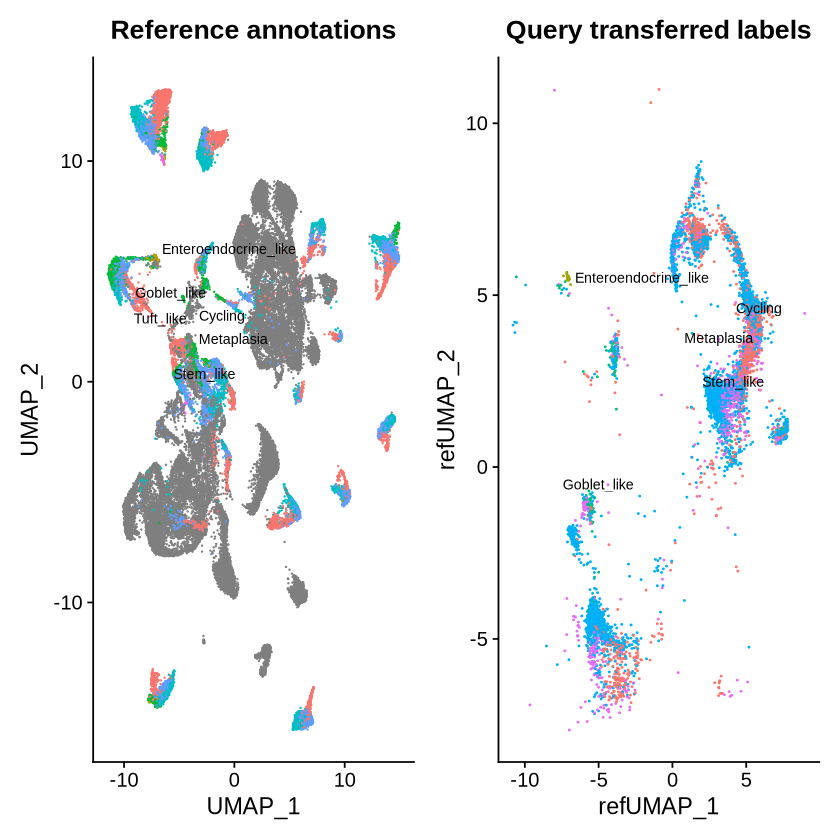

In [106]:
p1 <- DimPlot(tej, reduction = "umap", group.by = "celltype", label = TRUE, label.size = 3,
    repel = TRUE) + NoLegend() + ggtitle("Reference annotations")
p2 <- DimPlot(sdata, reduction = "ref.umap", group.by = "predicted.id", label = TRUE,
    label.size = 3, repel = TRUE) + NoLegend() + ggtitle("Query transferred labels")
p1 + p2

In [ ]:
#WTF!